# 04_03 Flow Strength (Gradient-Based Hydrological Potential)

## 1. Introduction

This notebook derives and visualizes a hydrological variable referred to as **flow strength**, computed directly from the spatial gradient of a digital elevation model (DEM).

Flow strength represents the **magnitude of elevation change across space**, and is used as a first-order proxy for terrain-driven potential energy that influences surface water movement.

### Flow Strength Definition

The flow strength field is defined as the magnitude of the spatial gradient of the elevation surface:

$$
\text{Flow Strength} = |\nabla z| =
\sqrt{
\left(\frac{\partial z}{\partial x}\right)^2 +
\left(\frac{\partial z}{\partial y}\right)^2
}
$$

Where:

- $z$ = elevation (m)
- $x, y$ = horizontal spatial coordinates (meters derived from projected DEM spacing)

This quantity represents the **absolute rate of change of elevation per unit distance**. 

In the simplest terms:

$$
\text{Flow Strength} = \frac{rise}{run}
$$

### Important clarification (Slope vs Flow Strength)

This is the same underlying gradient used in slope analysis.

However:

In the slope notebook:
  - the gradient is converted into **percent rise or angle**
  - interpretation focuses on **geometric steepness**

In this notebook:
  - the gradient is kept in its **raw magnitude form**
  - interpretation remains in **linear spatial units (m/m)**

So:

- **Slope** → transformed representation (angle / percent)
- **Flow strength** → raw gradient magnitude field (linear rate of change)

Both describe the same terrain property, but at different representation stages. 

This is similar to trigonometry and basic calculus interpretations of slope. In a 2D case, the slope of a line is defined as rise over run (y/x), and this can also be expressed as the tangent of an angle. From that we could compute the angle or percent rise , just as our previous slope data was computed from percent rise from the elevation gradient. In this case we want the slope as rise over run. 

For a surface, the idea generalizes: at every point on the terrain, we can imagine a plane tangent to the surface. The gradient describes the slope of that tangent plane, not a single line.

In this context, flow strength corresponds to the magnitude of that gradient — it is the steepest rate of change of elevation at that point, independent of direction. We are not interested in the angle of that slope, only how strong the change is in space.

### Units

Elevation is stored in meters, while horizontal spacing is derived from geographic coordinates (degrees) and converted into approximate meters using a latitude-based scaling factor.

Because of this:

- $z$ is in meters
- $x, y$ are in meters (after conversion from degrees → meters)

So the flow strength becomes:

Flow Strength ≈ m / m

This is a **dimensionless gradient magnitude**, representing how much elevation changes per unit horizontal distance.

It is not a velocity or discharge value — it is purely a terrain gradient field representing gravitational energy potential. That is to say when rain falls or rivers flow the water has initial velocity and other forces acting on it. The flow strength field doesn't account for that, but it can be used alongside the gradient direction to infer the direction that water would flow under idealized conditions where gravity-driven surface runoff dominates and other forces are neglected. Flow strength is a scalar field with magnitude only. To get the flow direction we need a vector with both magnitude and direction. That is covered in the next notebook.

### Why this variable exists

Even though slope already describes terrain steepness, the raw gradient field is useful because it:

- preserves continuous spatial variation
- avoids nonlinear transformation into angles or percentages
- allows direct comparison of terrain “energy structure”

This is especially useful in low-relief regions like Waterloo, where small variations in elevation still define drainage behavior.

## 2. Imports

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ipywidgets as widgets

## 3. Load DEM Data

In [4]:
with rasterio.open("../../data/clipped_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata

dem = np.where(dem == nodata, np.nan, dem)

## 4. Compute Flow Strength (Gradient Magnitude)

This is the **flow strength field**, computed directly from the DEM gradient.

In [5]:
# --- spatial scaling (convert degrees → meters) ---
rows, cols = dem.shape

mean_lat = (bounds.top + bounds.bottom) / 2
lat_m = 111320
lon_m = 111320 * np.cos(np.radians(mean_lat))

dx_spacing = lon_m * (bounds.right - bounds.left) / cols
dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

# --- gradient in physical space (meters) ---
dy, dx = np.gradient(dem, dy_spacing, dx_spacing)

# --- flow strength (m/m) ---
flow_strength = np.sqrt(dx**2 + dy**2)

## 5. 2D Visualization (Raw Flow Strength Field)

This plot shows the **absolute gradient magnitude field** without normalization.

It preserves the physical variation in terrain structure.

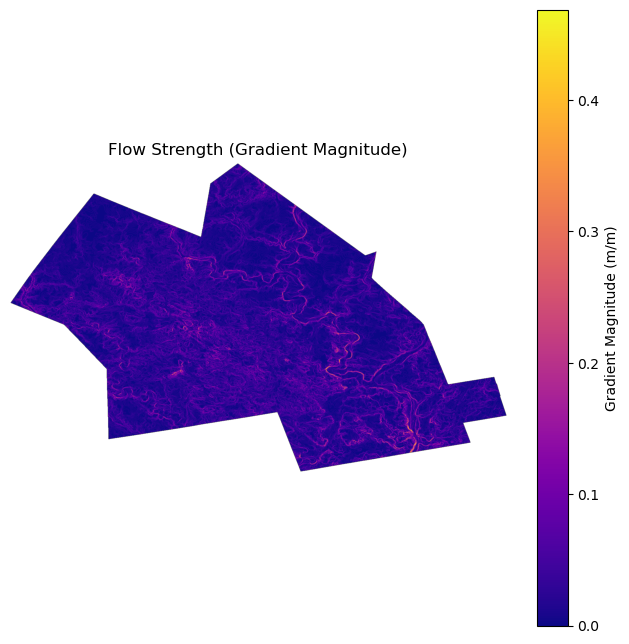

In [6]:

# IMPORTANT: 2D uses SAME physical gradient as 3D (for consistency)

plt.figure(figsize=(8, 8))

masked_flow = np.ma.masked_invalid(flow_strength)

plt.imshow(
    masked_flow,
    cmap="plasma",
    origin="upper"
)

plt.title("Flow Strength (Gradient Magnitude)")
plt.axis("off")

cbar = plt.colorbar()
cbar.set_label("Gradient Magnitude (m/m)")

plt.show()

## 6. 3D Terrain Model with Flow Strength Projection

This section projects the **flow strength field onto a 3D terrain surface**.

Key idea:

- Elevation defines geometry (z-axis)
- Flow strength defines color (scalar field)
- These are independent representations of the same terrain system
- Both can be viewed in one visualization

We also introduce interactive controls for:
- vertical exaggeration (visual relief enhancement)
- normalization (visual contrast scaling only)

Because the terrain surface is no longer colored based on elevation data, the visualtion can lack contrast in areas where flow strength is similar. The surface may appear as one color because changes in elevation are too subtle. It may become hard to see the elevation changes in such areas. Only high flow strength will be visible on the surface in that case. Adding normalization will bring the contrast back to make things more clear.  


### 3D Plot Function Definition

Note that many of the steps carried out here to build the 3D terrain model were discussed in the previous notebooks on elevation, so please refer back to those notebooks for clarification on any steps that are not clear. 

In [7]:
def plot_terrain(vertical_exaggeration=20, normalize=True):

    # --- spatial scaling ---
    mean_lat = (bounds.top + bounds.bottom) / 2
    lat_m = 111320
    lon_m = 111320 * np.cos(np.radians(mean_lat))

    rows, cols = dem.shape

    dx_spacing = lon_m * (bounds.right - bounds.left) / cols
    dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

    # --- SAME calculation as 2D plot ---
    dy, dx = np.gradient(
        dem,
        dy_spacing,
        dx_spacing
    )

    flow_strength = np.sqrt(dx**2 + dy**2)

    # mask invalid values exactly like 2D
    flow_strength = np.ma.masked_invalid(flow_strength)

    # --- physical extent in km ---
    width_km = (bounds.right - bounds.left) * lon_m / 1000
    height_km = (bounds.top - bounds.bottom) * lat_m / 1000

    x = np.linspace(0, width_km, cols)
    y = np.linspace(0, height_km, rows)

    # --- downsample ---
    step = 4

    z_small = dem[::step, ::step]
    flow_small = flow_strength[::step, ::step]

    x_small = x[::step]
    y_small = y[::step]

    # convert masked values to NaN for Plotly
    flow_small = flow_small.filled(np.nan)

    # --- orientation correction ---
    z_small = np.flipud(z_small)
    flow_small = np.flipud(flow_small)

    # --- elevation scaling only ---
    z_small = (z_small / 1000.0) * vertical_exaggeration

    # --- visualization field ---
    flow_vis = flow_small.copy()

    if normalize:

        low = np.nanpercentile(flow_vis, 1)
        high = np.nanpercentile(flow_vis, 99)

        flow_vis = np.clip(flow_vis, low, high)
        flow_vis = (flow_vis - low) / (high - low + 1e-9)

        cmin = 0
        cmax = 1
        color_title = "Normalized Flow Strength"

    else:

        # SAME range as the 2D plot
        cmin = np.nanmin(flow_strength)
        cmax = np.nanmax(flow_strength)

        color_title = "Flow Strength (m/m)"

    fig = go.Figure(
        data=[
            go.Surface(
                x=x_small,
                y=y_small,
                z=z_small,
                surfacecolor=flow_vis,
                colorscale="Emrld",
                cmin=cmin,
                cmax=cmax,
                colorbar=dict(title=color_title)
            )
        ]
    )

    fig.update_layout(
        title=f"Flow Strength on Terrain (Exaggeration {vertical_exaggeration}×, Normalize={normalize})",
        scene=dict(
            xaxis_title="Distance (km)",
            yaxis_title="Distance (km)",
            zaxis_title="Elevation (scaled)",
            aspectmode="manual",
            aspectratio=dict(
                x=width_km,
                y=height_km,
                z=np.nanmax(z_small) - np.nanmin(z_small)
            )
        )
    )

    fig.show()

### 3D Plot With Interactive Controls (Interpretation Layer)

Here we introduce interactive controls for:
- vertical exaggeration (visual relief enhancement)
- normalization (visual contrast scaling only) 

These controls affect perception, and are used for visualization only. 

Normalization is only used when we want:
- consistent color scaling
- improved visual contrast
- comparability across datasets
  
This is where the distinction between **absolute flow strength** and **normalized flow structure** becomes visually clear.

- Without normalization → raw terrain energy magnitude
- With normalization → relative spatial structure of flow potential
  
Normalization does not change the physics. It changes the question:

- Absolute view → “How steep is this exact point?”
- Normalized view →  “Where is the terrain most capable of driving motion relative to the rest of the region?”

This distinction becomes important in low-relief regions like Waterloo, where absolute slope values are small but spatial variation still controls drainage structure.

Vertical exaggeration similarly affects perception, not data.

In [8]:
widgets.interact(
    plot_terrain,
    vertical_exaggeration=widgets.IntSlider(value=20, min=1, max=30, step=1),
    normalize=widgets.Checkbox(value=False, description="Normalize Flow Strength")
)

interactive(children=(IntSlider(value=20, description='vertical_exaggeration', max=30, min=1), Checkbox(value=…

<function __main__.plot_terrain(vertical_exaggeration=20, normalize=True)>

## 7. Interpretation of the 3D Projection

This visualization combines two independent fields:

- **Elevation (geometry)** → defines terrain structure
- **Flow strength (color)** → defines spatial gradient intensity

Key interpretation rules:

- Height = terrain shape only
- Color = hydrological potential field
- No coupling between them in computation

### Normalization interpretation

Without normalization:
- shows absolute gradient magnitude
- emphasizes physical variation but can appear visually flat in low-relief regions

With normalization:

- We shift the question from “how strong is flow” to “where is flow most likely relative to surrounding terrain”

This is especially useful in flat landscapes like Waterloo Region, where:
- absolute gradients are small
- but relative differences control drainage pathways

Thus normalization is not a distortion — it is a **change in analytical question**, from magnitude to structure. If the land is mostly flat flow is not really visible. Normalization helps to reveal hidden areas where water may flow. When water has momentum and velocity the magnitude of flow strength is less important than direction for determining where water may settle or accumulate.

### Flow Strength Interpretation

High elevation does not imply high flow strength.

- Flat highlands can have low flow strength
- Low valleys can have high flow strength
- The controlling factor is **rate of elevation change**, not absolute height

Flow strength therefore acts as a way to visualize **terrain change intensity**, not elevation itself. Without these visual modfications to the Z-Scale and the Normalization of flow strength, changes would be imperciptable in these visualizations... however the changes are present and do drive water flow so the modifcations help us see patterns that would otherwise be hidden.